=== 5 Data Teratas ===
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1   

=== Unique value pada kolom 'Personal Loan' ===
Personal Loan
0    4

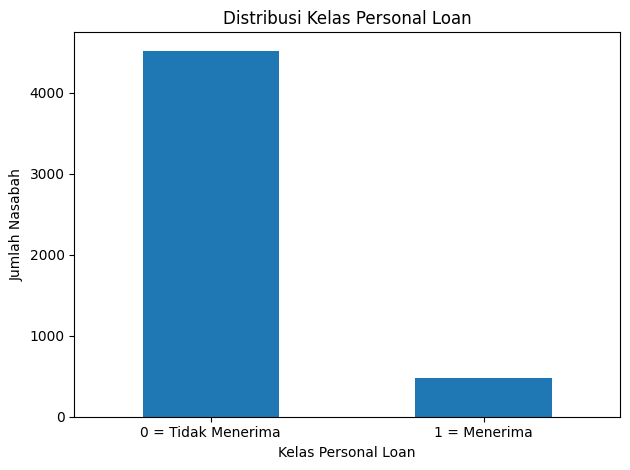

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("dataset/bank_personal_loan_data.csv")

# Cek 5 baris pertama
print("=== 5 Data Teratas ===")
print(df.head(), "\n")

# 2. Cek kolom target & value unique
print("=== Unique value pada kolom 'Personal Loan' ===")
print(df["Personal Loan"].value_counts(), "\n")

# 3. Distribusi kelas 0 dan 1 (jumlah & persentase)
class_counts = df["Personal Loan"].value_counts().sort_index()
class_percent = df["Personal Loan"].value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "Kelas": ["0 = Tidak Menerima Loan", "1 = Menerima Loan"],
    "Jumlah": class_counts.values,
    "Persentase (%)": class_percent.round(2).values
})

print("=== Distribusi Kelas Personal Loan ===")
print(dist_df, "\n")

# 4. Statistik deskriptif keseluruhan (hanya kolom numerik, TANPA ID & ZIP Code)
drop_cols = ["ID", "ZIP Code"]  # kolom yang tidak ingin ditampilkan

numeric_all = df.select_dtypes(include=["int64", "float64"]).columns
numeric_for_desc = [c for c in numeric_all if c not in drop_cols]

print("=== Statistik Deskriptif Keseluruhan (Numerik, tanpa ID & ZIP Code) ===")
print(df[numeric_for_desc].describe().T, "\n")

# 5. Statistik per kelas (rata-rata tiap fitur untuk kelas 0 dan 1)
#    gunakan list yang sama (numeric_for_desc) supaya konsisten
#    (Personal Loan nanti otomatis tidak dihitung karena dipakai sebagai 'by' di groupby)
numeric_cols = [c for c in numeric_for_desc if c != "Personal Loan"]

mean_by_class = df.groupby("Personal Loan")[numeric_cols].mean().T

print("=== Rata-rata Fitur per Kelas Personal Loan (tanpa ID & ZIP Code) ===")
print(mean_by_class, "\n")

# 6. (Opsional) Plot bar distribusi kelas
plt.figure()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["0 = Tidak Menerima", "1 = Menerima"], rotation=0)
plt.xlabel("Kelas Personal Loan")
plt.ylabel("Jumlah Nasabah")
plt.title("Distribusi Kelas Personal Loan")
plt.tight_layout()
plt.show()


=== Proporsi Varian yang Dijelaskan oleh Setiap PC ===
      PC  Explained Variance Ratio  Cumulative Variance
0    PC1                  0.186228             0.186228
1    PC2                  0.168765             0.354993
2    PC3                  0.128575             0.483568
3    PC4                  0.092379             0.575947
4    PC5                  0.090668             0.666614
5    PC6                  0.089407             0.756021
6    PC7                  0.084447             0.840468
7    PC8                  0.081643             0.922111
8    PC9                  0.046484             0.968595
9   PC10                  0.030919             0.999513
10  PC11                  0.000487             1.000000 



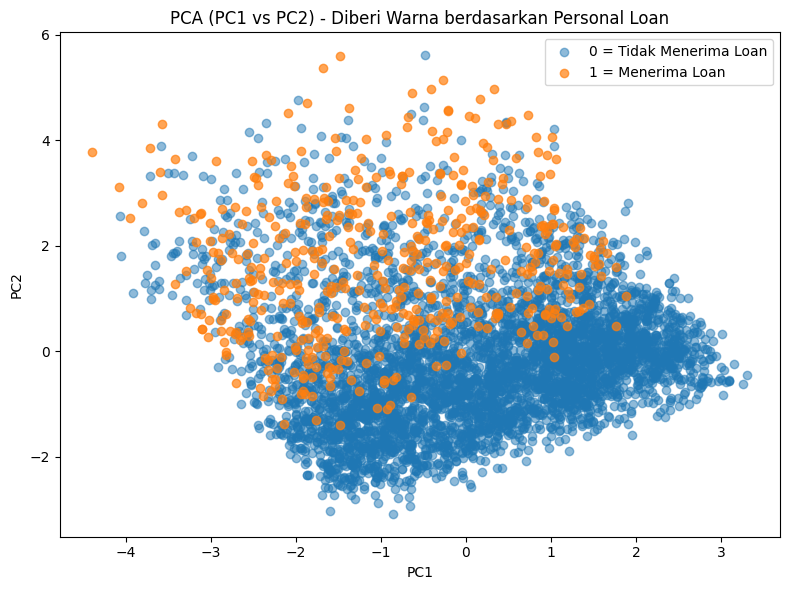

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ================================
# 1. Load dataset
# ================================
df = pd.read_csv("dataset/bank_personal_loan_data.csv")

# ================================
# 2. Pisahkan X (11 fitur) dan y (Personal Loan)
# ================================
feature_cols = [
    "Age",
    "Experience",
    "Income",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard"
]

X = df[feature_cols]
y = df["Personal Loan"]   # target (0 / 1)

# ================================
# 3. Standardisasi fitur (wajib untuk PCA)
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 4. PCA: hitung semua komponen
# ================================
pca = PCA(n_components=len(feature_cols))  # sebanyak jumlah fitur
X_pca = pca.fit_transform(X_scaled)

# ================================
# 5. Tampilkan proporsi varian yang dijelaskan
# ================================
explained_var = pca.explained_variance_ratio_
explained_var_cum = explained_var.cumsum()

pca_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(feature_cols))],
    "Explained Variance Ratio": explained_var,
    "Cumulative Variance": explained_var_cum
})

print("=== Proporsi Varian yang Dijelaskan oleh Setiap PC ===")
print(pca_df, "\n")

# ================================
# 6. Visualisasi PCA 2D (PC1 vs PC2) dengan warna berdasarkan y
# ================================
plt.figure(figsize=(8, 6))

# Ambil PC1 dan PC2
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Plot, dibedakan berdasarkan kelas Personal Loan
plt.scatter(pc1[y == 0], pc2[y == 0], alpha=0.5, label="0 = Tidak Menerima Loan")
plt.scatter(pc1[y == 1], pc2[y == 1], alpha=0.7, label="1 = Menerima Loan")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2) - Diberi Warna berdasarkan Personal Loan")
plt.legend()
plt.tight_layout()
plt.show()


Explained variance ratio (PC1–PC3): [0.18622775 0.16876493 0.12857527]
Cumulative: [0.18622775 0.35499268 0.48356795] 



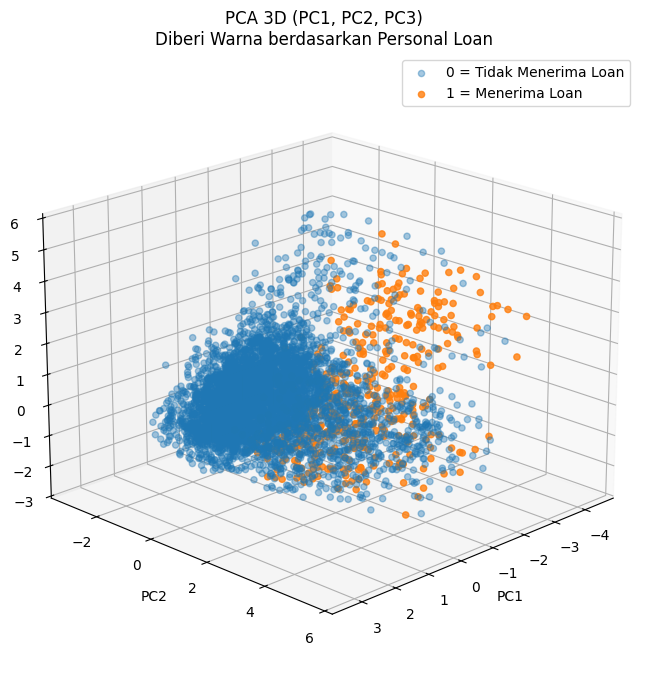

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # kadang tidak wajib, tapi aman ditambahkan

# ================================
# 1. Load dataset
# ================================
df = pd.read_csv("dataset/bank_personal_loan_data.csv")

# ================================
# 2. Pisahkan X (11 fitur) dan y (Personal Loan)
# ================================
feature_cols = [
    "Age",
    "Experience",
    "Income",
    "Family",
    "CCAvg",
    "Education",
    "Mortgage",
    "Securities Account",
    "CD Account",
    "Online",
    "CreditCard"
]

X = df[feature_cols]
y = df["Personal Loan"]

# ================================
# 3. Standardisasi fitur
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 4. PCA dengan 3 komponen
# ================================
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pc1 = X_pca_3d[:, 0]
pc2 = X_pca_3d[:, 1]
pc3 = X_pca_3d[:, 2]

# (opsional) cek berapa varian yang dijelaskan
print("Explained variance ratio (PC1–PC3):", pca_3d.explained_variance_ratio_)
print("Cumulative:", pca_3d.explained_variance_ratio_.cumsum(), "\n")

# ================================
# 5. Plot PCA 3D
# ================================
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# kelas 0
ax.scatter(
    pc1[y == 0],
    pc2[y == 0],
    pc3[y == 0],
    alpha=0.4,
    label="0 = Tidak Menerima Loan"
)

# kelas 1
ax.scatter(
    pc1[y == 1],
    pc2[y == 1],
    pc3[y == 1],
    alpha=0.8,
    label="1 = Menerima Loan"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D (PC1, PC2, PC3)\nDiberi Warna berdasarkan Personal Loan")
ax.legend()

# 👉 ubah sudut pandang di sini
ax.view_init(elev=20, azim=45)   # coba angka lain: elev=10/30, azim=0/90/135/180

plt.tight_layout()
plt.show()


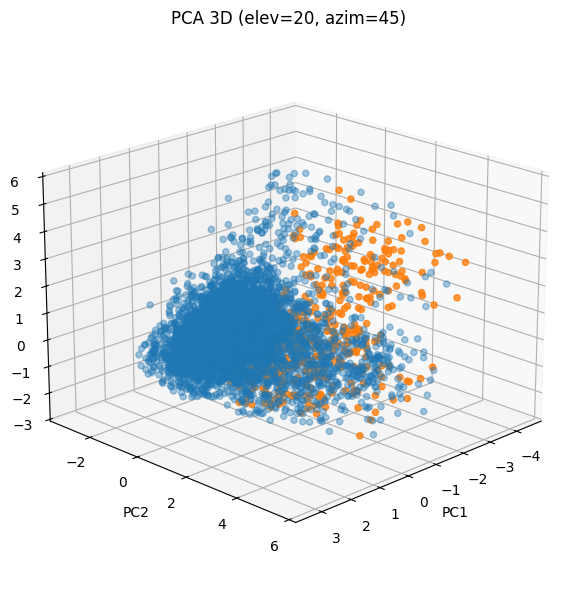

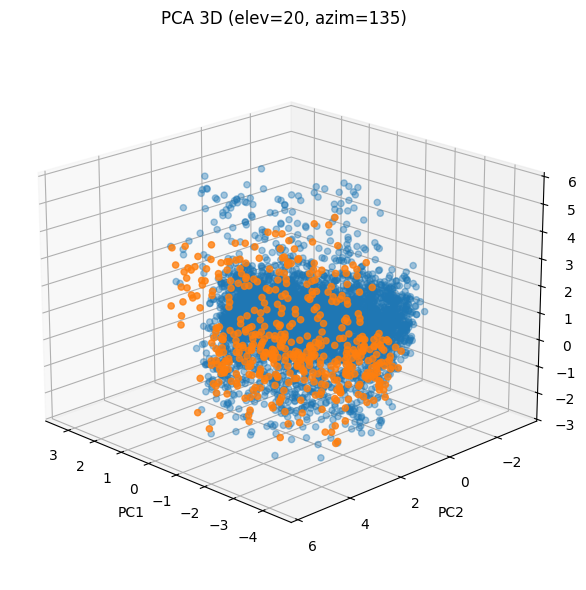

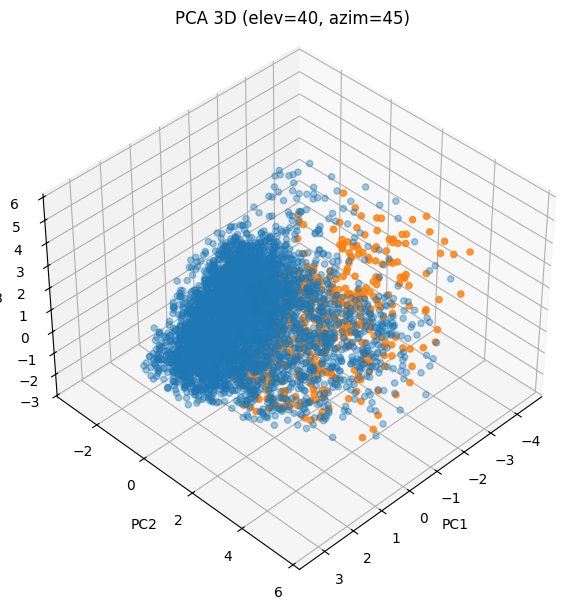

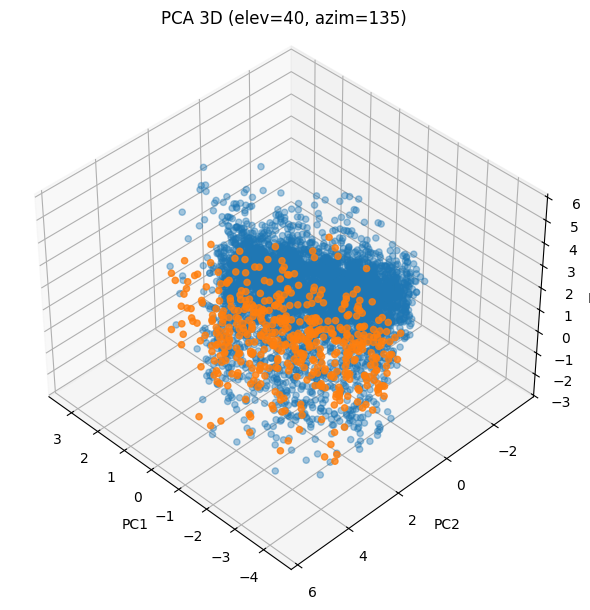

In [9]:
for elev, azim in [(20, 45), (20, 135), (40, 45), (40, 135)]:
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pc1[y==0], pc2[y==0], pc3[y==0], alpha=0.4)
    ax.scatter(pc1[y==1], pc2[y==1], pc3[y==1], alpha=0.8)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.set_title(f"PCA 3D (elev={elev}, azim={azim})")
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()
